# 17 – Spektralanalyse

Die **Fourier-Transformation** und ihre diskrete Variante (**DFT/FFT**) sind zentral in der Kommunikationstechnik: Signale im Frequenzbereich analysieren, Kanäle charakterisieren, Rauschen und Störungen bewerten. In diesem Kapitel erzeugst du ein **Sinussignal mit überlagertem Rauschen**, lernst die **FFT in Python** (NumPy) kennen, diskutierst die **Skalierung** des Spektrums und ermittelst das **Maximum** im Spektrum. Abschließend: **spektrale Auflösung** und **Wertebereich** des Spektrums.

**Navigation:** [← 16_Dictionaries](../16_Dictionaries/16_Dictionaries.ipynb) | 17_Spektralanalyse | [→ Übersicht](../README.md)

## Signal: Sinus 50 Hz, 2 V, Abtastrate 1 kHz + AWGN

Wir erzeugen **1024 Abtastpunkte**: Sinus mit $f = 50\,\mathrm{Hz}$, Amplitude $A = 2\,\mathrm{V}$, Abtastrate $f_s = 1\,\mathrm{kHz}$. Dazu addieren wir **AWGN** (mittelwertfrei) mit Standardabweichung $\sigma = 0{,}2\,\mathrm{V}$, um ein realistisches Messsignal zu simulieren.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fs = 1000.0   # Abtastrate in Hz
N = 1024      # Anzahl Punkte
f = 50.0      # Signalfrequenz in Hz
A = 2.0       # Amplitude in V
sigma = 0.2   # AWGN: Standardabweichung in V

t = np.arange(N) / fs
sinus = A * np.sin(2 * np.pi * f * t)
rauschen = np.random.normal(0, sigma, N)
signal = sinus + rauschen

print(f"N = {N}, f_s = {fs} Hz, f = {f} Hz, A = {A} V, \u03c3 = {sigma} V")
print(f"Zeitdauer: {N/fs:.3f} s")


N = 1024, f_s = 1000.0 Hz, f = 50.0 Hz, A = 2.0 V, σ = 0.2 V
Zeitdauer: 1.024 s


## Plot des Zeitsignals

Darstellung des Signals (Sinus + Rauschen) über der Zeit.

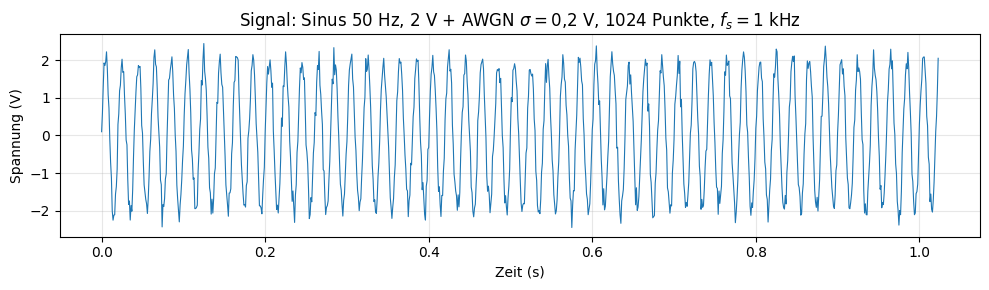

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(t, signal, color="C0", linewidth=0.8)
plt.xlabel("Zeit (s)")
plt.ylabel("Spannung (V)")
plt.title(r"Signal: Sinus 50 Hz, 2 V + AWGN $\sigma = 0{,}2$ V, 1024 Punkte, $f_s = 1$ kHz")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## FFT in Python: Welche Methoden?

Die **schnelle Fourier-Transformation (FFT)** berechnet die **diskrete Fourier-Transformation (DFT)** effizient. In Python nutzt man dafür:

- **`np.fft.fft(x)`** – FFT des Signals `x`; liefert komplexe Spektralwerte.
- **`np.fft.fftfreq(n, d)`** – zugehörige **Frequenzachse**: `n` = Länge des Signals, `d` = Abtastintervall ($1/f_s$). Liefert Frequenzen von $-f_s/2$ bis (nahe) $+f_s/2$ in der für `fft` üblichen Anordnung (erst positive, dann negative Frequenzen).
- **`np.fft.ifft`** – inverse FFT.

Weitere Varianten: `np.fft.rfft` (nur positive Frequenzen für reelle Signale), `np.fft.fftshift` (Frequenzachse zentriert um 0). Für die Analyse reeller Signale reicht `fft` + `fftfreq`; oft betrachtet man nur den Bereich $0 \ldots f_s/2$ (einseitiges Spektrum).

## FFT berechnen und Spektrum darstellen

Wir rufen **`np.fft.fft(signal)`** auf und verwenden **`np.fft.fftfreq(N, 1/fs)`** für die Frequenzachse. Der **Betrag** des Spektrums wird mit **`np.abs(...)`** gebildet.

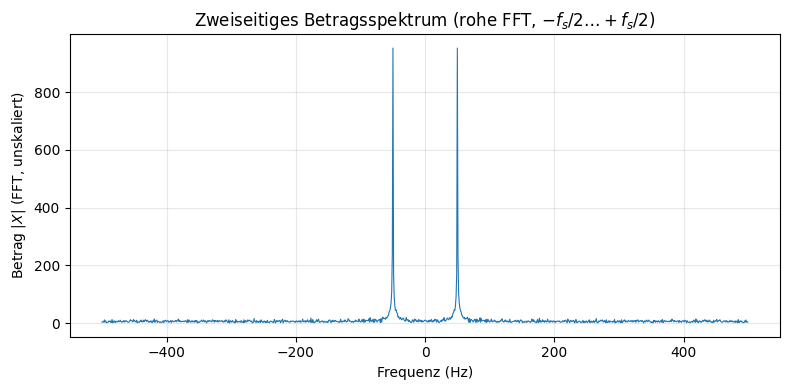

In [8]:
X = np.fft.fft(signal)
freq = np.fft.fftfreq(N, 1 / fs)
magnitude = np.abs(X)
# Zweiseitiges Spektrum: Frequenzachse zentrieren (0 in der Mitte, $-f_s/2 \ldots +f_s/2$)
freq_shifted = np.fft.fftshift(freq)
magnitude_shifted = np.fft.fftshift(magnitude)

plt.figure(figsize=(8, 4))
plt.plot(freq_shifted, magnitude_shifted, color="C0", linewidth=0.8)
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Betrag $|X|$ (FFT, unskaliert)")
plt.title("Zweiseitiges Betragsspektrum (rohe FFT, $-f_s/2 \ldots +f_s/2$)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Skalierung des Spektrums und sichtbarer Bereich

**Skalierung:** `np.fft.fft` normiert **nicht** durch $N$. Für ein reelles Sinussignal mit Amplitude $A$ hat die FFT im positiven Frequenzbereich einen Betrag von etwa $A \cdot N/2$. Will man ein **Amplitudenspektrum** (so dass die Höhe des Peaks der Amplitude $A$ entspricht), skaliert man oft mit **$2/N$** (einseitig, nur positive Frequenzen). Dann entspricht die Peak-Höhe näherungsweise der Amplitude der Sinuskomponente.

**Sichtbarer Bereich:** Bei einem **reellen** Zeitsignal ist das Spektrum **konjugiert gerade** ($X(-f) = X^*(f)$). Es reicht, den Bereich **$0 \leq f \leq f_s/2$** (Nyquist-Bereich) darzustellen. Die Frequenzachse von `fftfreq` liefert zuerst positive Frequenzen (0 bis $f_s/2$), dann negative. Für ein einseitiges Amplitudenspektrum wählt man die ersten $N/2+1$ Werte und skaliert mit $2/N$.

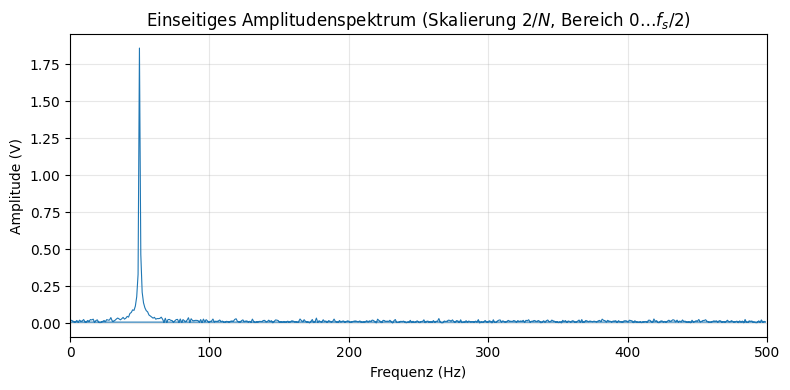

In [9]:
# Einseitiges Spektrum: nur positive Frequenzen, Skalierung 2/N für Amplitudenspektrum
n_pos = N // 2 + 1
freq_einseitig = freq[:n_pos]
magnitude_einseitig = np.abs(X[:n_pos]) * (2.0 / N)

plt.figure(figsize=(8, 4))
plt.plot(freq_einseitig, magnitude_einseitig, color="C0", linewidth=0.8)
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Amplitude (V)")
plt.title(r"Einseitiges Amplitudenspektrum (Skalierung $2/N$, Bereich $0 \ldots f_s/2$)")
plt.xlim(0, fs / 2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Position und Wert des Maximums im Spektrum

Das **Maximum** des (skalierten) Amplitudenspektrums liefert die **dominante Frequenz** und die zugehörige **Amplitude**. Wir nutzen **`np.argmax`** für den Index und lesen Frequenz sowie Amplitudenwert ab. Der Index 0 (Gleichanteil) wird oft ausgelassen, wenn nur Wechselanteile interessieren.

In [10]:
# Maximum im einseitigen Spektrum (ohne Gleichanteil index 0)
idx_max = 1 + np.argmax(magnitude_einseitig[1:])
f_max = freq_einseitig[idx_max]
A_max = magnitude_einseitig[idx_max]

print(f"Maximum im Spektrum: Index {idx_max}")
print(f"Frequenz beim Maximum: f_max = {f_max:.2f} Hz")
print(f"Amplitude beim Maximum: A_max = {A_max:.4f} V")
print(f"(Zum Vergleich: Soll Frequenz {f} Hz, Soll-Amplitude {A} V)")


Maximum im Spektrum: Index 51
Frequenz beim Maximum: f_max = 49.80 Hz
Amplitude beim Maximum: A_max = 1.8600 V
(Zum Vergleich: Soll Frequenz 50.0 Hz, Soll-Amplitude 2.0 V)


## Woraus ergeben sich spektrale Auflösung und Wertebereich?

**Spektrale Auflösung:** Die FFT liefert $N$ Spektralwerte im Frequenzbereich $[0, f_s)$ (bzw. $[-f_s/2, f_s/2)$ mit `fftshift`). Der **Frequenzabstand** zwischen zwei benachbarten FFT-Bins ist
$$ \Delta f = \frac{f_s}{N} \,. $$
Das ist die **spektrale Auflösung**: Zwei Sinuskomponenten können nur dann getrennt werden, wenn sie mindestens etwa $\Delta f$ auseinander liegen. Mit $f_s = 1000\,\mathrm{Hz}$ und $N = 1024$ ergibt sich $\Delta f \approx 0{,}98\,\mathrm{Hz}$.

**Wertebereich des Spektrums:**
- **Frequenzachse:** Bei einseitiger Darstellung $0 \ldots f_s/2$ (Nyquist-Frequenz). Bei zweiseitiger Darstellung $-f_s/2 \ldots +f_s/2$.
- **Amplitudenachse:** Nach Skalierung mit $2/N$ entspricht die Höhe eines Peaks näherungsweise der Amplitude der zugehörigen Sinuskomponente im Zeitsignal. Ohne Skalierung sind die FFT-Beträge von der Länge $N$ und der Signalenergie abhängig.

**Kurz:** Auflösung $\Delta f = f_s/N$; sichtbarer Frequenzbereich bis $f_s/2$; Amplitudenskala durch $2/N$ für einseitiges Amplitudenspektrum.

## Vertiefung: Amplitudenspektrum und Leistungsspektrum (dBm)

Im Vertiefungsnotebook [**17_Spektralanalyse_Amplituden_Leistungsspektrum.ipynb**](17_Spektralanalyse_Amplituden_Leistungsspektrum.ipynb) werden das **Amplitudenspektrum** (lineare und logarithmische y-Achse) und das **Leistungsspektrum** in **dBm** mit demselben verrauschten Sinussignal dargestellt, inkl. Marker und Beschriftung sowie dem Zusammenhang zwischen beiden Darstellungen.


## Kurz zusammengefasst

| Thema | Inhalt |
|-------|--------|
| **Signal** | Sinus + AWGN mit $N$, $f_s$, $f$, $A$, $\sigma$; Zeitsignal plotten. |
| **FFT in Python** | `np.fft.fft(x)`, `np.fft.fftfreq(n, 1/fs)`; Betrag mit `np.abs`. |
| **Skalierung** | Einseitiges Amplitudenspektrum: positive Frequenzen, Skalierung $2/N$. |
| **Sichtbarer Bereich** | $0 \ldots f_s/2$ (reelles Signal). |
| **Maximum** | `np.argmax` für Index, Frequenz und Amplitude aus dem skalierten Spektrum ablesen. |
| **Spektrale Auflösung** | $\Delta f = f_s/N$. |
| **Wertebereich Frequenz** | Bis $f_s/2$ (einseitig). |

Damit hast du die Grundlagen, um in Python Signale spektral zu analysieren und Frequenz sowie Amplitude aus der FFT zu gewinnen.

---

**Zurück:** [← 16_Dictionaries](../16_Dictionaries/16_Dictionaries.ipynb) | [Übersicht Python-Grundkurs](../README.md)